## **STEP 1:**
**Setup and Data Loading**:
Install libraries and load the dataset from a public GitHub raw URL.

In [17]:
# Install if needed (usually pre-installed in Colab)
!pip install pandas scikit-learn matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Load dataset (fake_job_postings.csv - 18 cols: text + categorical + target 'fraudulent')
url = 'https://raw.githubusercontent.com/Erfaniaa/fake-job-posting-detection/master/dataset.csv'
df = pd.read_csv(url)
print(df.shape)
print(df['fraudulent'].value_counts())
df.head()

(17880, 18)
fraudulent
0    17014
1      866
Name: count, dtype: int64


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## **STEP 2:**

**Data Exploration:**
Check missing values, distributions, and visualize fraud rate. Fake jobs often lack company logos or have vague locations.

In [18]:
# Basic info
print(df.info())
print('\nMissing values:\n', df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

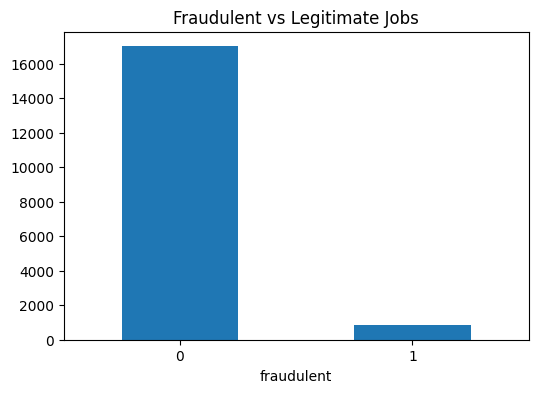

In [19]:
# Target distribution
plt.figure(figsize=(6,4))
df['fraudulent'].value_counts().plot(kind='bar')
plt.title('Fraudulent vs Legitimate Jobs')
plt.xticks(rotation=0)
plt.show()



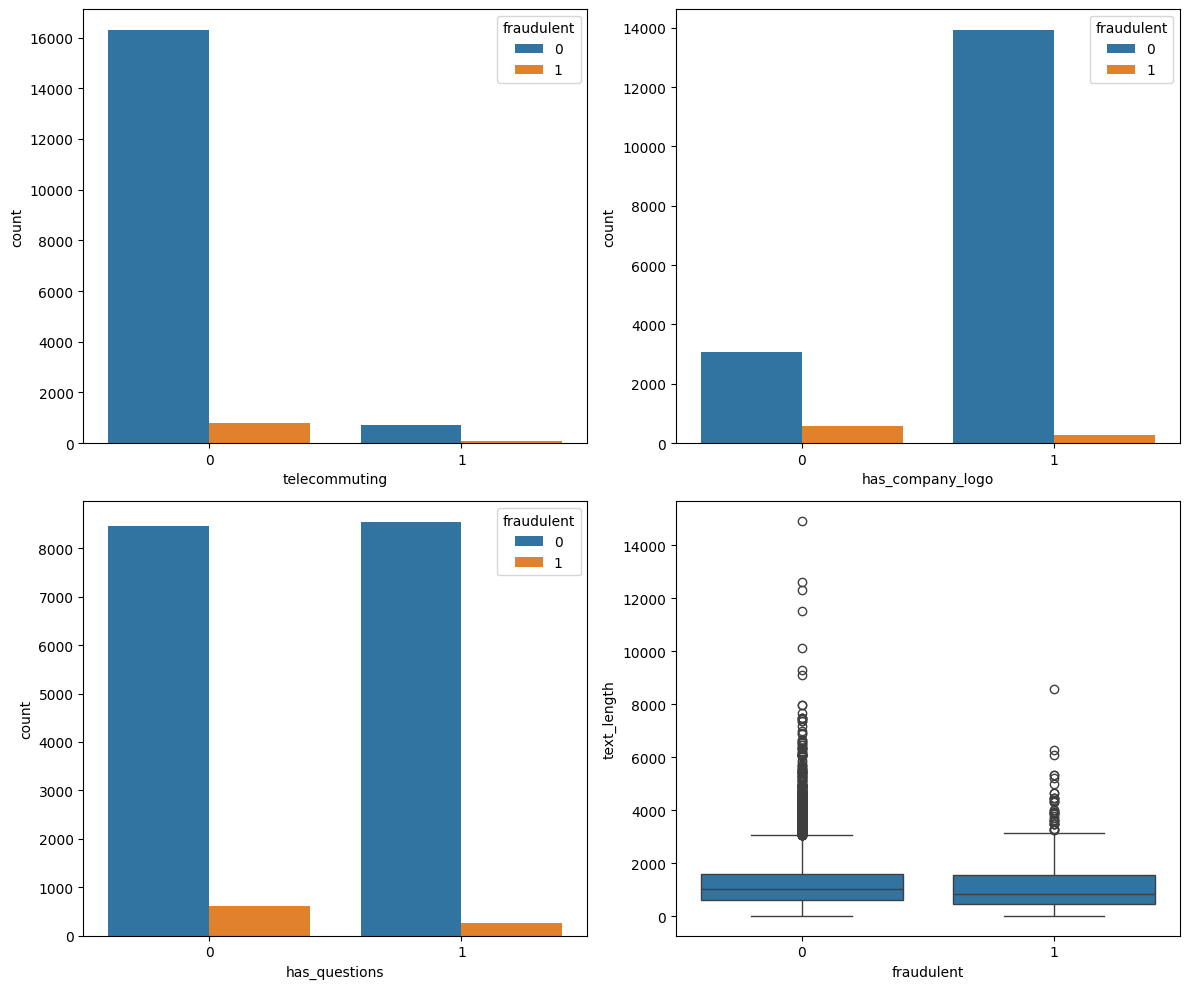

In [20]:
# Features overview
fig, axes = plt.subplots(2,2, figsize=(12,10))
sns.countplot(data=df, x='telecommuting', hue='fraudulent', ax=axes[0,0])
sns.countplot(data=df, x='has_company_logo', hue='fraudulent', ax=axes[0,1])
sns.countplot(data=df, x='has_questions', hue='fraudulent', ax=axes[1,0])
df['text_length'] = df['description'].str.len()
sns.boxplot(data=df, x='fraudulent', y='text_length', ax=axes[1,1])
plt.tight_layout()
plt.show()

# **STEP 3:**

**Text Preprocessing:**
Clean text (title + description + requirements) and handle missing values. Convert to TF-IDF for numerical features.

In [21]:
# Simple cleaning function
def clean_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    return text

# Combine key text fields
df['combined_text'] = (df['title'].fillna('') + ' ' +
                       df['description'].fillna('') + ' ' +
                       df['requirements'].fillna(''))
df['combined_text'] = df['combined_text'].apply(clean_text)

# Fill categorical NAs
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
for col in cat_cols:
    df[col] = df[col].fillna('unknown')

# Encode categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Numerical features
num_cols = ['telecommuting', 'has_company_logo', 'has_questions']

## **STEP 4:**

**Feature Engineering and Split:**
TF-IDF on text (max 5000 features for speed); add nums/categoricals. Split 80/20.



In [22]:
# TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_text = vectorizer.fit_transform(df['combined_text'])

# Other features
X_num_cat = df[num_cols + cat_cols].values

# Combine (horizontal stack)
from scipy.sparse import hstack
X = hstack([X_text, X_num_cat])

y = df['fraudulent']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)

(14304, 5008)


## **STEP 5:**

**Model Training:**
Train Logistic Regression and Naive Bayes. No scaling needed for these (TF-IDF is normalized).

In [23]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('LR Accuracy:', accuracy_score(y_test, y_pred_lr))

LR Accuracy: 0.9678411633109619


In [24]:
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print('NB Accuracy:', accuracy_score(y_test, y_pred_nb))

NB Accuracy: 0.9295302013422819


# **STEP 6:**

**Model Evaluation:**
Use precision/recall/F1 (key for imbalanced data: focus on detecting fakes). Compare models

In [25]:
# Metrics
print('Logistic Regression:')
print(classification_report(y_test, y_pred_lr))

print('Naive Bayes:')
print(classification_report(y_test, y_pred_nb))



Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.98      0.34      0.51       173

    accuracy                           0.97      3576
   macro avg       0.98      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576

Naive Bayes:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3403
           1       0.28      0.29      0.29       173

    accuracy                           0.93      3576
   macro avg       0.62      0.63      0.63      3576
weighted avg       0.93      0.93      0.93      3576



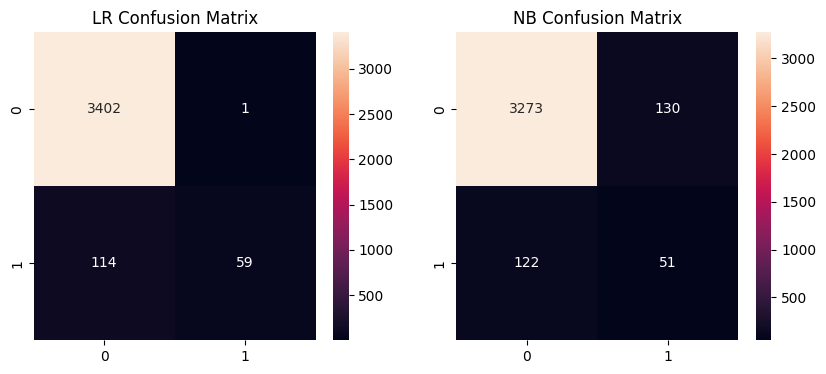

In [26]:
# Confusion matrices
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('LR Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('NB Confusion Matrix')
plt.show()

# **STEP 7:**

**Prediction System: **
Test on new posting. Handles text cleaning automatically.

In [27]:
def predict_job(posting_text):
    clean = clean_text(posting_text)
    text_vec = vectorizer.transform([clean])
    num_cat_dummy = np.zeros((1, len(num_cols + cat_cols)))  # Defaults: no telecommute/logo/questions, unknown cats
    X_new = hstack([text_vec, num_cat_dummy])
    lr_pred = lr.predict(X_new)[0]
    lr_prob = lr.predict_proba(X_new)[0][1]
    return 'Fraudulent' if lr_pred == 1 else 'Legitimate', lr_prob

# Example
new_posting = "Urgent!! Senior Python Developer needed ASAP. Send resume and $500 fee to email."
result, prob = predict_job(new_posting)
print(f'Prediction: {result} (Fake prob: {prob:.2%})')

Prediction: Legitimate (Fake prob: 39.25%)
